# Warehouse Operational Efficiency — Performance Analysis
### SupplyFlow FMCG Solutions | Data Science Capstone Project

| | |
|---|---|
| **Student** | Deepesh Kumar Gautam |
| **USN** | 233VBBR00561 |
| **Elective** | Data Science |
| **Project** | Analyzing Warehouse Operational Efficiency |

---
**Business Goal:** Identify the key operational factors that drive warehouse throughput across the FMCG supply chain and build a predictive model to support resource allocation and performance improvement decisions.

**Target Variable:** `product_wg_ton` — total product weight shipped per warehouse (proxy for operational throughput/efficiency)

**ML Task:** Regression — predict continuous shipment output and rank operational feature influence.

## 0. Setup & Library Imports
*All libraries required for data processing, visualization, and machine learning.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading & Initial Overview
*Loading the SupplyFlow FMCG dataset — first inspection of shape, types, and content before any processing.*

In [ ]:
# Load dataset — update path if running locally
df = pd.read_excel('/content/SupplyFlow FMCG Solutions.xlsx')

print(f"Dataset Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names & Data Types:")
print(df.dtypes.to_string())

Dataset Shape  : 25,000 rows × 24 columns

Column Names & Data Types:
Ware_house_ID                    object
WH_Manager_ID                    object
Location_type                    object
WH_capacity_size                 object
zone                             object
WH_regional_zone                 object
num_refill_req_l3m                int64
transport_issue_l1y               int64
Competitor_in_mkt                 int64
retail_shop_num                   int64
wh_owner_type                    object
distributor_num                   int64
flood_impacted                    int64
flood_proof                       int64
electric_supply                   int64
dist_from_hub                     int64
workers_num                     float64
wh_est_year                     float64
storage_issue_reported_l3m        int64
temp_reg_mach                     int64
approved_wh_govt_certificate     object
wh_breakdown_l3m                  int64
govt_check_l3m                    int64
product_wg

In [ ]:
# Preview first five records
df.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071


In [ ]:
# Descriptive statistics for all numerical features
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
num_refill_req_l3m,25000.0,4.09,2.61,0.0,2.0,4.0,6.0,8.0
transport_issue_l1y,25000.0,0.77,1.20,0.0,0.0,0.0,1.0,5.0
Competitor_in_mkt,25000.0,3.10,1.14,0.0,2.0,3.0,4.0,12.0
retail_shop_num,25000.0,4985.71,1052.83,1821.0,4313.0,4859.0,5500.0,11008.0
distributor_num,25000.0,42.42,16.06,15.0,29.0,42.0,56.0,70.0
flood_impacted,25000.0,0.10,0.30,0.0,0.0,0.0,0.0,1.0
flood_proof,25000.0,0.05,0.23,0.0,0.0,0.0,0.0,1.0
electric_supply,25000.0,0.66,0.47,0.0,0.0,1.0,1.0,1.0
dist_from_hub,25000.0,163.54,62.72,55.0,109.0,164.0,218.0,271.0
workers_num,24010.0,28.94,7.87,10.0,24.0,28.0,33.0,98.0


## 2. Data Quality Assessment
*Verifying data types, identifying missing values, and checking for duplicates before analysis.*

In [ ]:
# Data type verification — confirming all columns are stored as expected
dtype_check = pd.DataFrame({
    'Column'       : df.columns,
    'Stored As'    : df.dtypes.values,
    'Null Count'   : df.isnull().sum().values,
    'Null %'       : (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique Values': df.nunique().values
}).reset_index(drop=True)

print("=== Data Type & Quality Report ===")
print(dtype_check.to_string(index=False))
print(f"\nDuplicate Rows : {df.duplicated().sum()}")
print("\nNote: All columns are stored in expected types.")
print("      workers_num / wh_est_year as float64 due to missing values — correct.")
print("      No dtype corrections required before analysis.")

=== Data Type & Quality Report ===
                      Column Stored As  Null Count  Null %  Unique Values
               Ware_house_ID    object           0    0.00          25000
               WH_Manager_ID    object           0    0.00          25000
               Location_type    object           0    0.00              2
            WH_capacity_size    object           0    0.00              3
                        zone    object           0    0.00              4
            WH_regional_zone    object           0    0.00              6
          num_refill_req_l3m     int64           0    0.00              9
         transport_issue_l1y     int64           0    0.00              6
           Competitor_in_mkt     int64           0    0.00             12
             retail_shop_num     int64           0    0.00           4906
               wh_owner_type    object           0    0.00              2
             distributor_num     int64           0    0.00             56
   

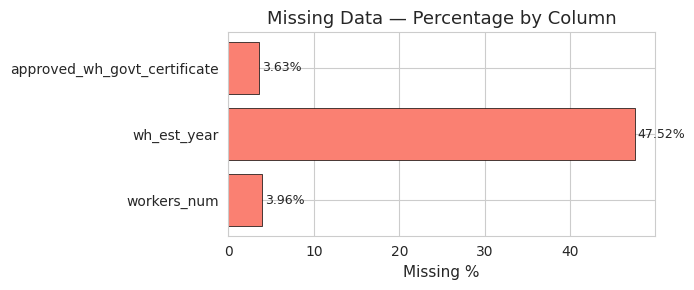

Key observations:
  wh_est_year   : 47.5% missing — high; median imputation + feature engineering applied later
  workers_num   : 3.96% missing  — low; median imputation sufficient
  approved_wh_govt_certificate : 3.63% missing — low; mode imputation applied


In [ ]:
# Visualise missing data distribution
missing_only = dtype_check[dtype_check['Null Count'] > 0][['Column','Null %']]

plt.figure(figsize=(7, 3))
plt.barh(missing_only['Column'], missing_only['Null %'],
         color='salmon', edgecolor='black', linewidth=0.5)
plt.title('Missing Data — Percentage by Column')
plt.xlabel('Missing %')
for i, val in enumerate(missing_only['Null %']):
    plt.text(val + 0.3, i, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  wh_est_year   : 47.5% missing — high; median imputation + feature engineering applied later")
print("  workers_num   : 3.96% missing  — low; median imputation sufficient")
print("  approved_wh_govt_certificate : 3.63% missing — low; mode imputation applied")

## 3. Exploratory Data Analysis (EDA)
*EDA is performed to extract business insights from the data — not just to execute code.
Each analysis is followed by an interpretation connecting the finding to warehouse operations.*

### 3.1 Target Variable — `product_wg_ton`
*Understanding the distribution of warehouse shipment weight before any modelling.*

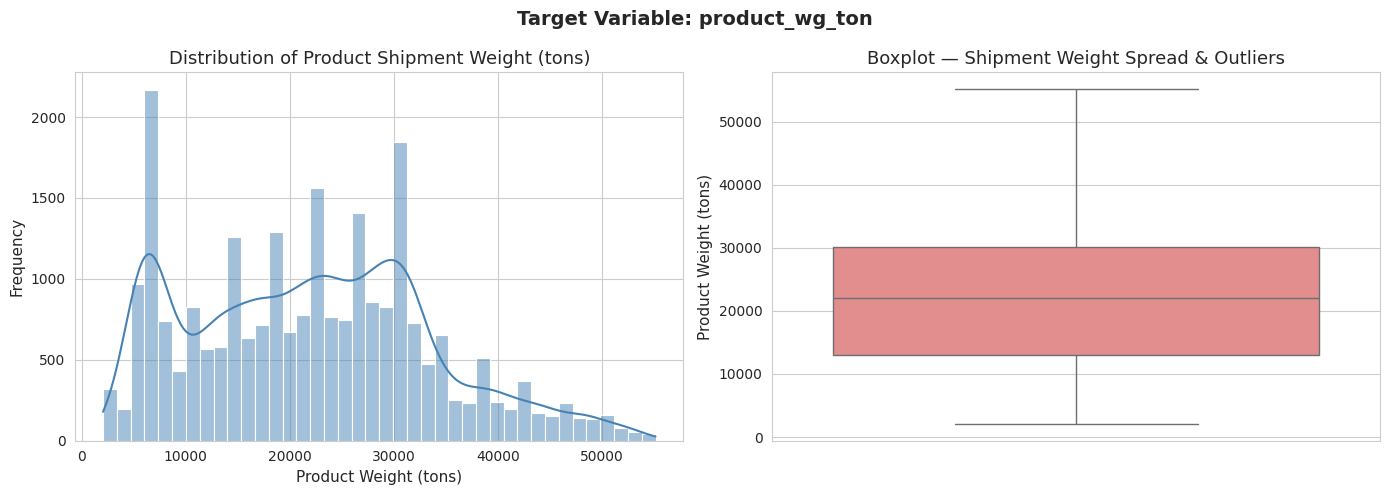

Mean   : 22,103 tons
Median : 22,101 tons
Std Dev: 11,608 tons
Skew   : 0.3316


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['product_wg_ton'], kde=True, bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Product Shipment Weight (tons)')
axes[0].set_xlabel('Product Weight (tons)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['product_wg_ton'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot — Shipment Weight Spread & Outliers')
axes[1].set_ylabel('Product Weight (tons)')

plt.suptitle('Target Variable: product_wg_ton', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean   : {df['product_wg_ton'].mean():,.0f} tons")
print(f"Median : {df['product_wg_ton'].median():,.0f} tons")
print(f"Std Dev: {df['product_wg_ton'].std():,.0f} tons")
print(f"Skew   : {df['product_wg_ton'].skew():.4f}")

**Business Insight:** The near-symmetric distribution (skew = 0.33) with mean ≈ median (22,103 vs 22,101 tons) indicates that most warehouses operate around a consistent central throughput level. The wide standard deviation (~11,600 tons) reveals significant performance variation across the network — meaning some warehouses are substantially more efficient than others. This variance is what the model aims to explain.

### 3.2 Categorical Feature Distributions
*Composition of the warehouse network by type, location, zone, and ownership.*

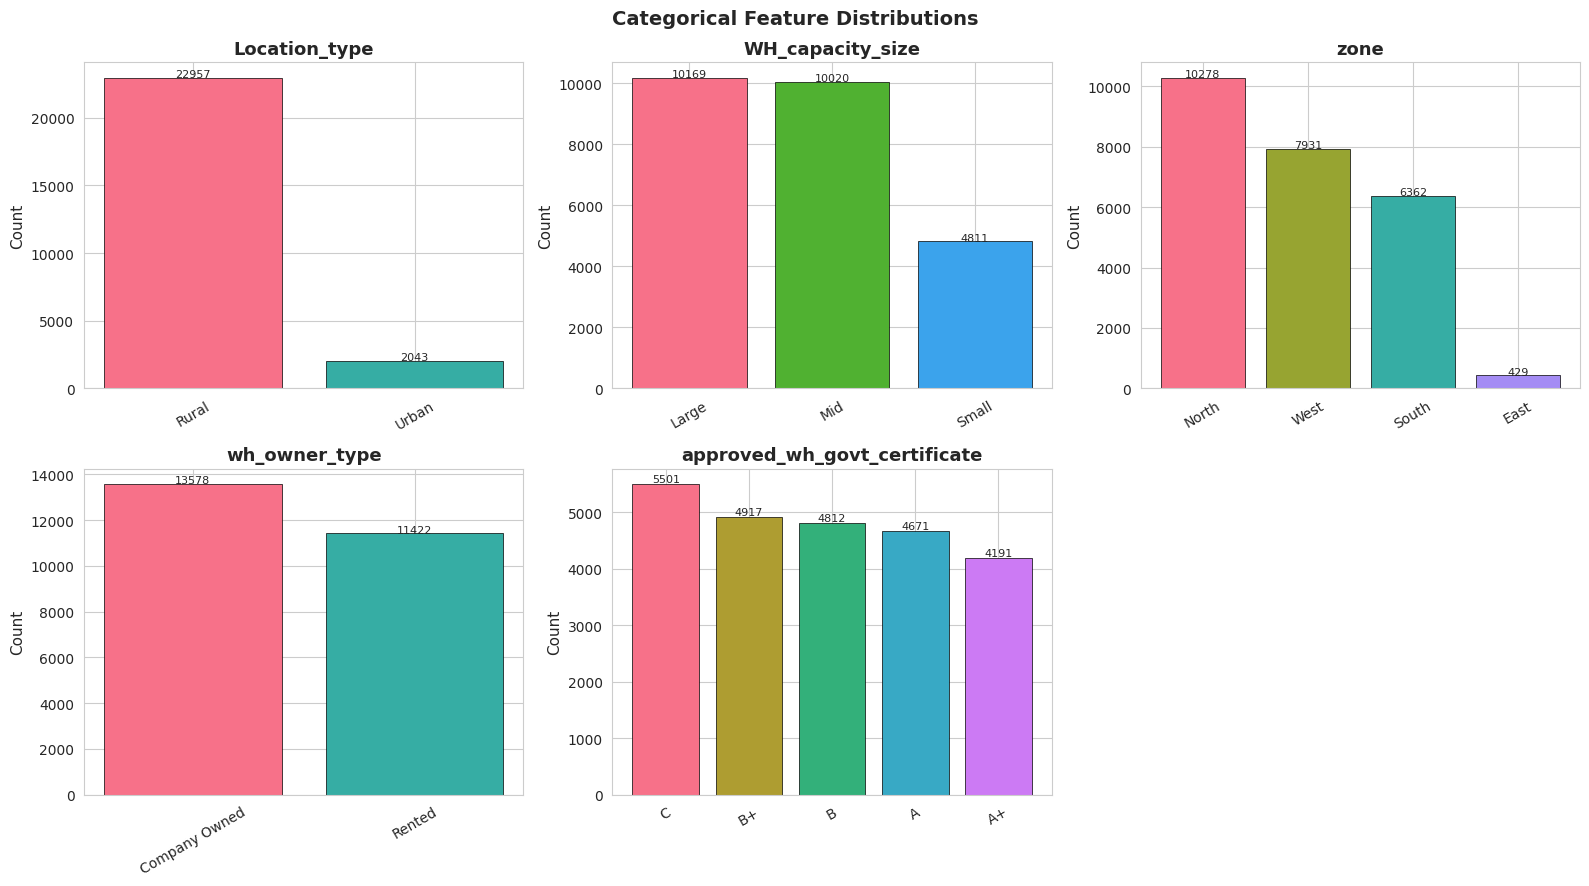

In [ ]:
cat_cols = ['Location_type', 'WH_capacity_size', 'zone',
            'wh_owner_type', 'approved_wh_govt_certificate']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       color=sns.color_palette('husl', len(counts)),
                       edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 30, str(val), ha='center', fontsize=8)

axes[5].axis('off')
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight:** Rural warehouses outnumber Urban, suggesting the network is spread across lower-density areas where last-mile logistics is more complex. The majority of warehouses hold a Grade A government certificate, indicating a generally compliant network. However, the presence of lower-grade certified warehouses is worth monitoring — compliance level is linked to operational standards and throughput, as shown in later analysis.

### 3.3 Average Shipment Weight by Business Category — Bivariate Analysis
*Comparing throughput across zones, size, location, and ownership to identify performance gaps.*

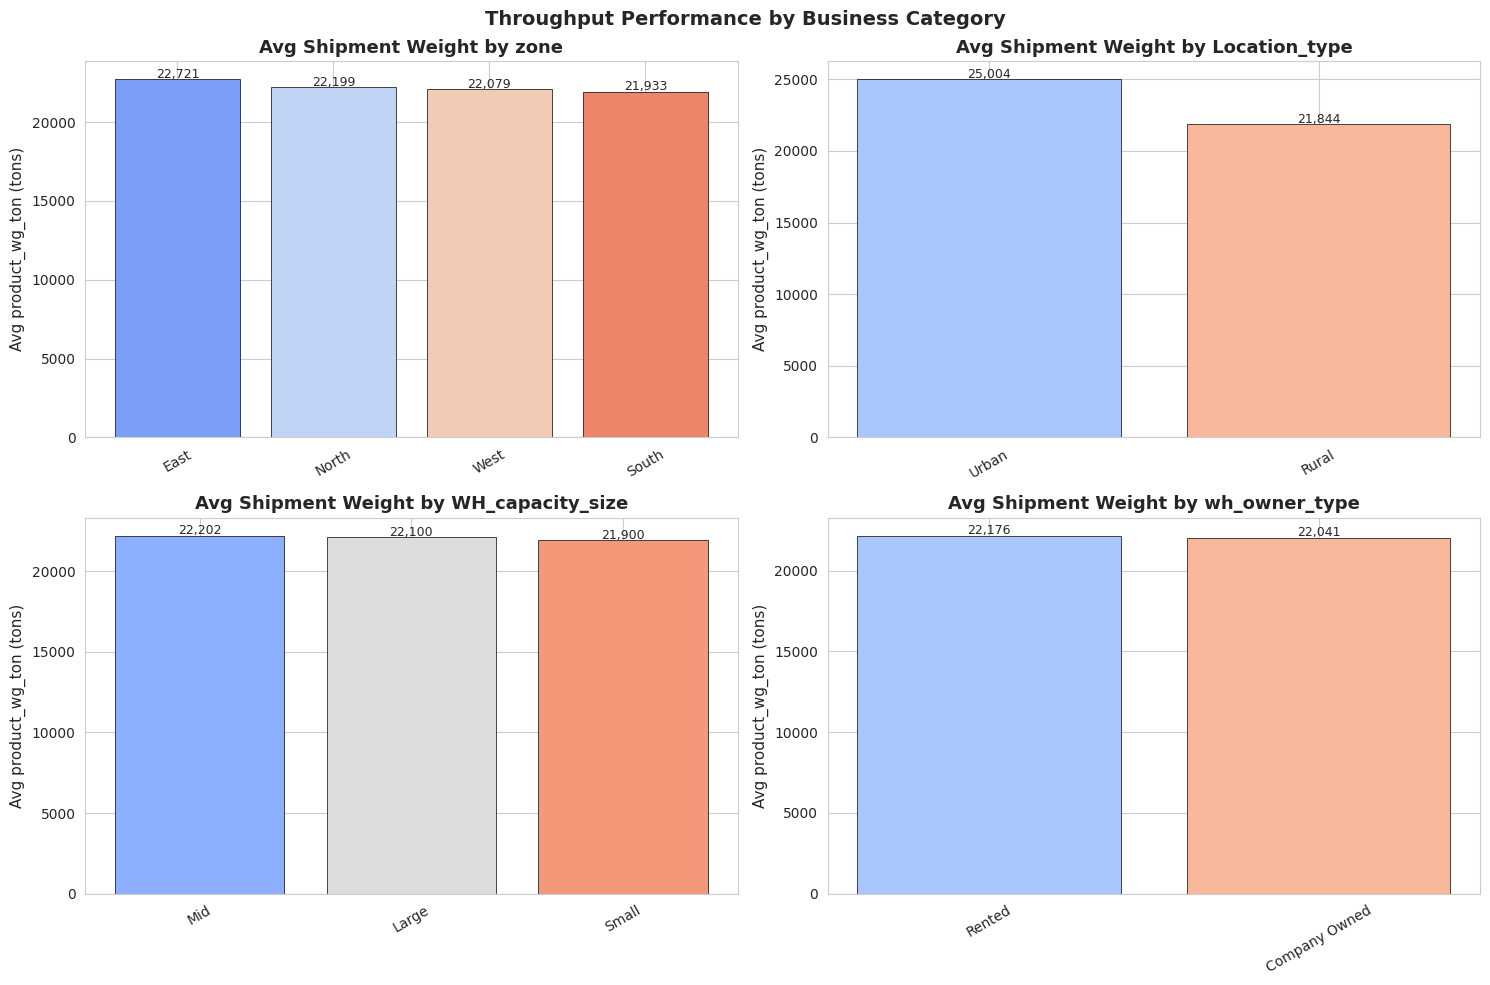

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
group_cols = ['zone', 'Location_type', 'WH_capacity_size', 'wh_owner_type']

for ax, col in zip(axes.flatten(), group_cols):
    avg = df.groupby(col)['product_wg_ton'].mean().sort_values(ascending=False)
    bars = ax.bar(avg.index, avg.values,
                  color=sns.color_palette('coolwarm', len(avg)),
                  edgecolor='black', linewidth=0.5)
    ax.set_title(f'Avg Shipment Weight by {col}', fontweight='bold')
    ax.set_ylabel('Avg product_wg_ton (tons)')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 80, f'{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Throughput Performance by Business Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight:**
- **Zone:** North and West zones show higher average throughput than South and East, indicating uneven demand distribution across the FMCG network. East zone warehouses may need distributor expansion to lift performance.
- **Capacity Size:** Larger warehouses handle proportionally more product weight, but the gap between Mid and Large is smaller than expected — suggesting capacity alone does not drive efficiency.
- **Ownership:** Company-owned warehouses modestly outperform rented ones, likely because owned sites allow greater infrastructure investment and operational control.
- **Location:** Urban vs Rural difference is observable — Urban warehouses serve denser retail networks, driving higher shipment frequency.

### 3.4 Numerical Feature Distributions — Univariate Analysis
*Reviewing shape and spread of all key operational variables; skewness informs preprocessing decisions.*

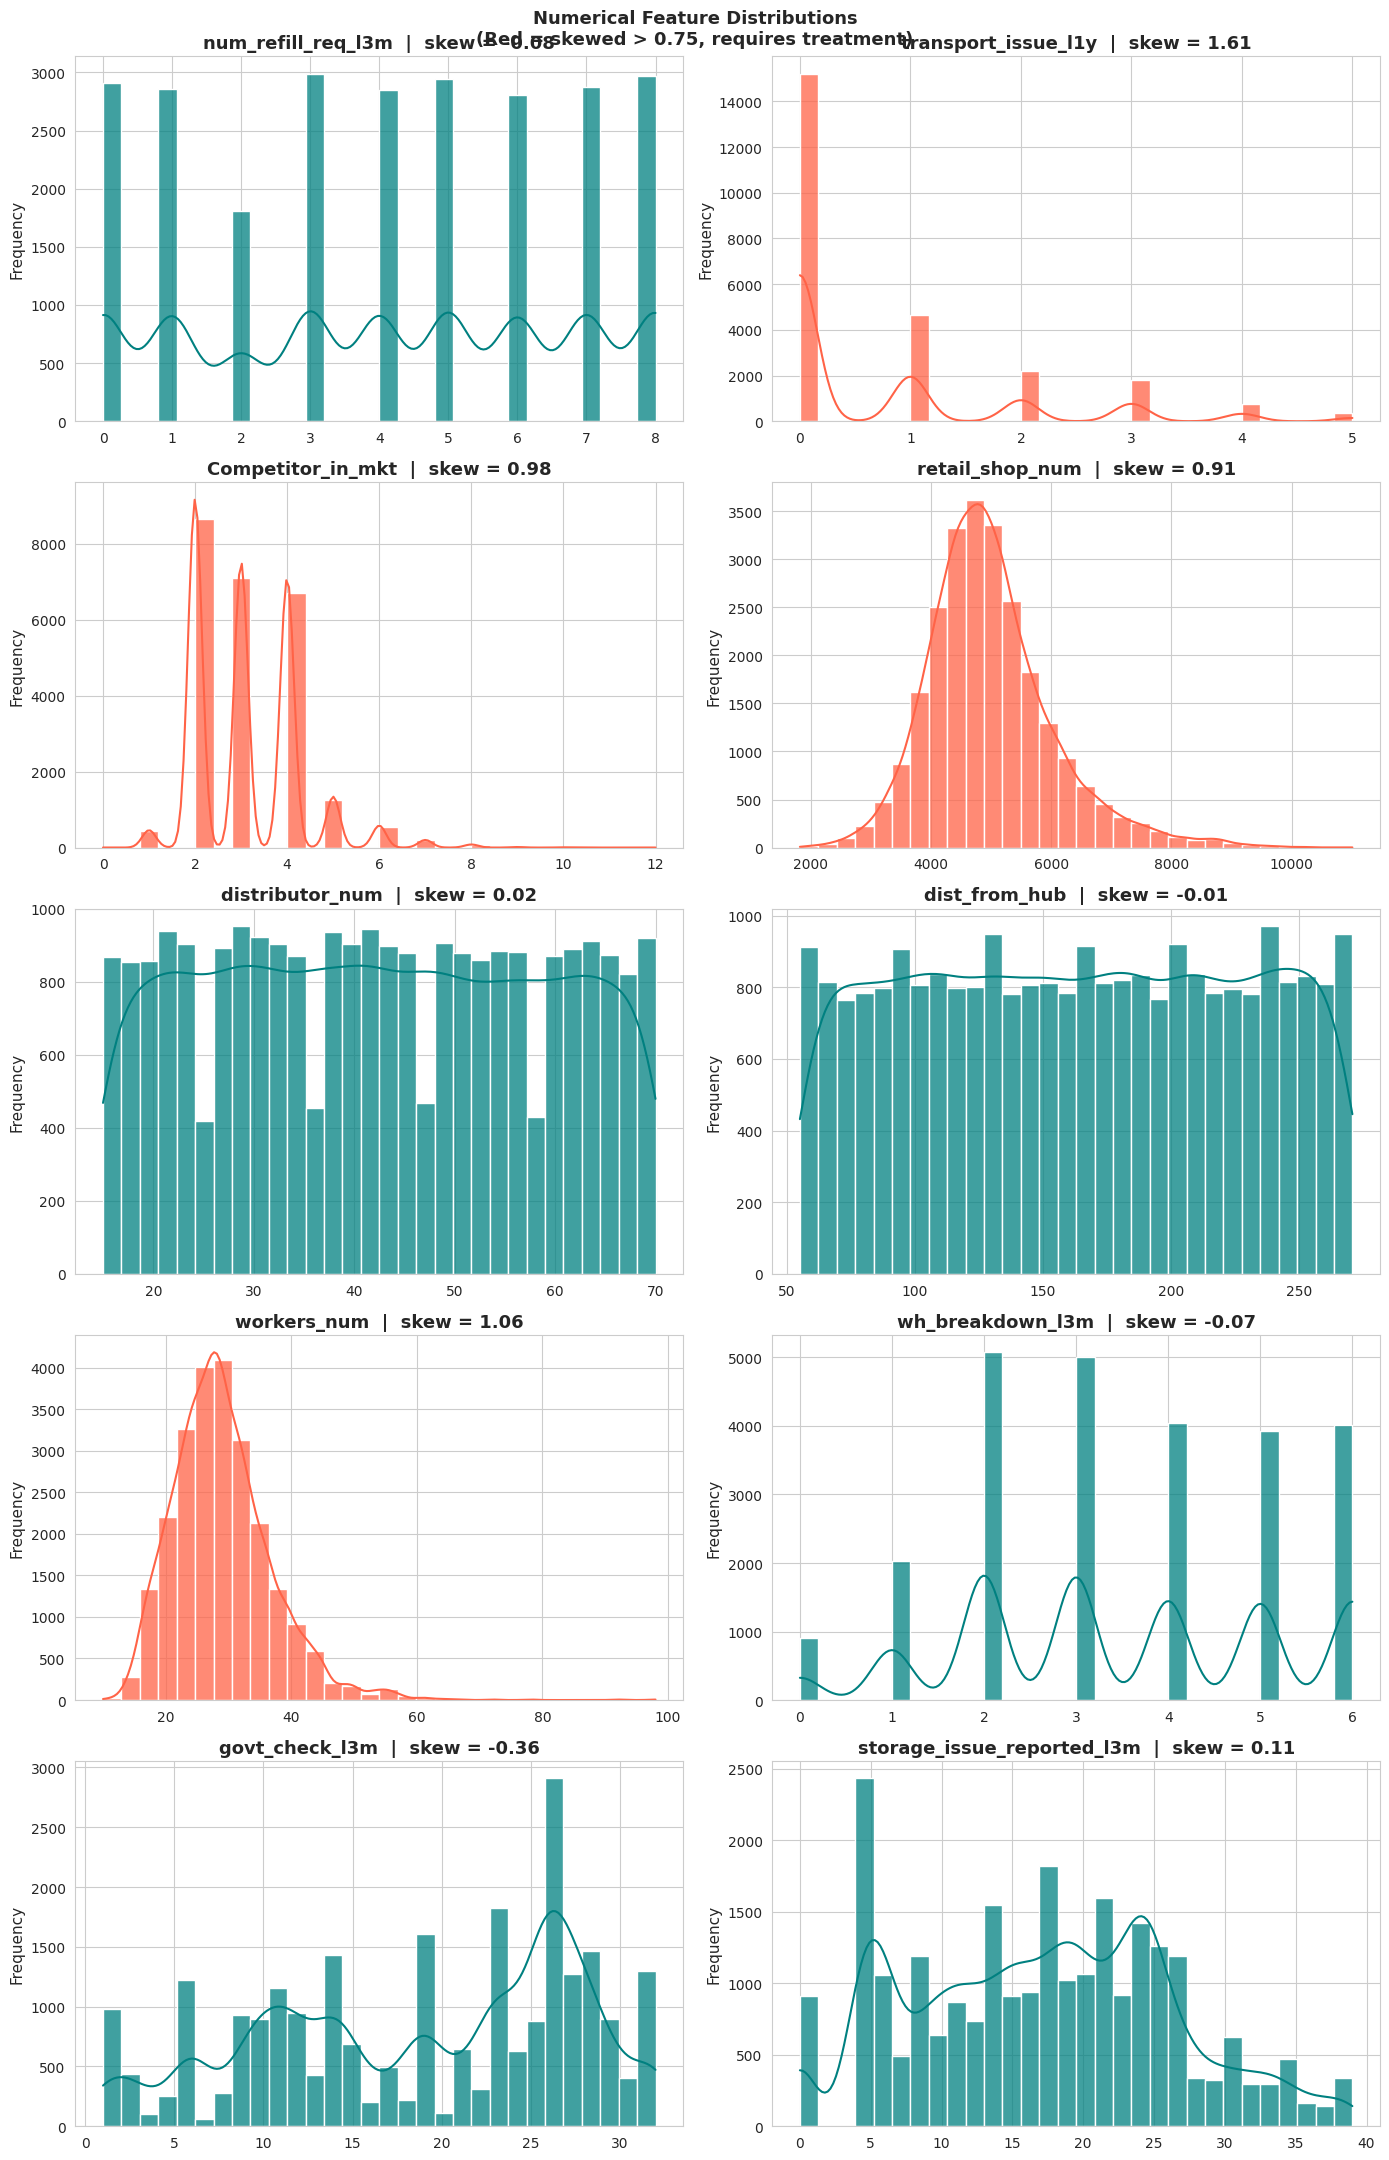

Skewness Summary:
  num_refill_req_l3m                 : -0.075  ✓ acceptable
  transport_issue_l1y                :  1.611  ⚠ HIGH — log transform applied in preprocessing
  Competitor_in_mkt                  :  0.978  ⚠ HIGH — log transform applied in preprocessing
  retail_shop_num                    :  0.908  ⚠ HIGH — log transform applied in preprocessing
  distributor_num                    :  0.015  ✓ acceptable
  dist_from_hub                      : -0.006  ✓ acceptable
  workers_num                        :  1.060  ⚠ HIGH — log transform applied in preprocessing
  wh_breakdown_l3m                   : -0.068  ✓ acceptable
  govt_check_l3m                     : -0.363  ✓ acceptable
  storage_issue_reported_l3m         :  0.113  ✓ acceptable


In [ ]:
num_cols_eda = ['num_refill_req_l3m', 'transport_issue_l1y', 'Competitor_in_mkt',
                'retail_shop_num', 'distributor_num', 'dist_from_hub',
                'workers_num', 'wh_breakdown_l3m', 'govt_check_l3m',
                'storage_issue_reported_l3m']

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    data = df[col].dropna()
    sk   = data.skew()
    color = 'tomato' if abs(sk) > 0.75 else 'teal'
    sns.histplot(data, bins=30, kde=True, ax=axes[i], color=color, alpha=0.75)
    axes[i].set_title(f'{col}  |  skew = {sk:.2f}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Numerical Feature Distributions\n(Red = skewed > 0.75, requires treatment)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Skewness Summary:")
for col in num_cols_eda:
    sk = df[col].skew()
    flag = '⚠ HIGH — log transform applied in preprocessing' if abs(sk) > 0.75 else '✓ acceptable'
    print(f"  {col:35s}: {sk:>6.3f}  {flag}")

**Business Insight:** `transport_issue_l1y` (skew 1.61) and `workers_num` (skew 1.06) are notably right-skewed, indicating most warehouses have low transport disruptions and moderate workforce, but a small number experience disproportionately high values. These extremes, if untreated, would pull the model toward outlier-driven patterns rather than typical operational behaviour. Log transformation is applied in the preprocessing stage to correct this.

### 3.5 Key Numerical Features vs Target — Bivariate Analysis
*Scatter plots reveal the direction and strength of the relationship between operational variables and warehouse shipment weight.*

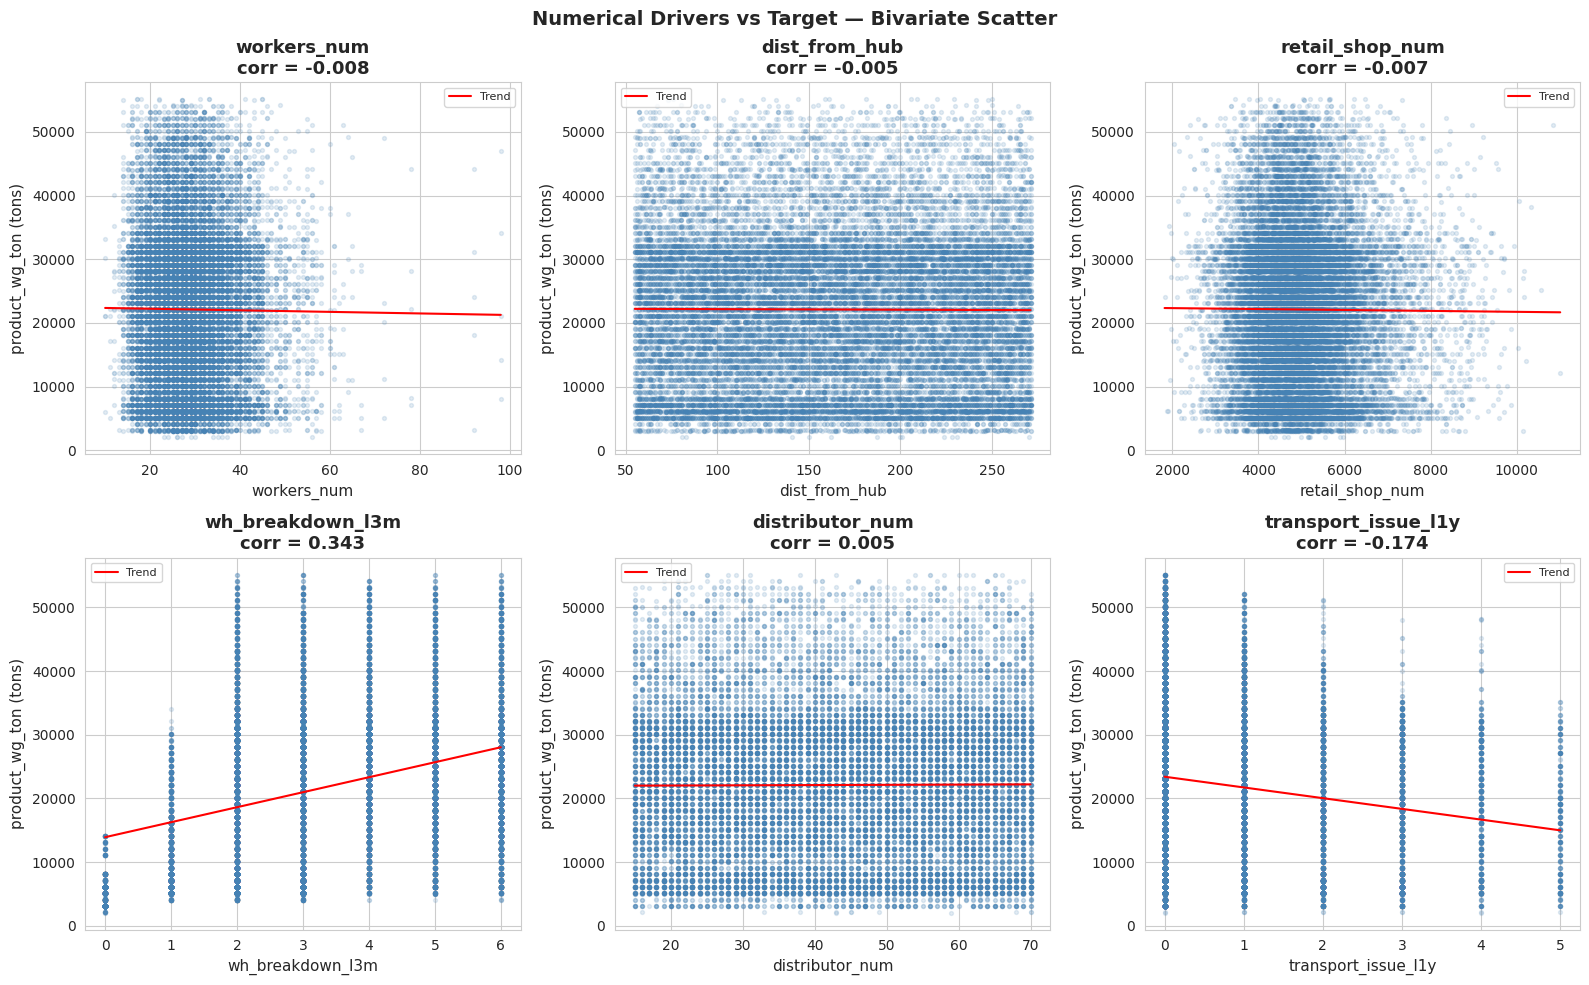

In [ ]:
scatter_cols = ['workers_num', 'dist_from_hub', 'retail_shop_num',
                'wh_breakdown_l3m', 'distributor_num', 'transport_issue_l1y']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_cols):
    data = df[[col, 'product_wg_ton']].dropna()
    axes[i].scatter(data[col], data['product_wg_ton'],
                    alpha=0.15, color='steelblue', s=8)
    # Trend line
    z = np.polyfit(data[col], data['product_wg_ton'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[col].min(), data[col].max(), 200)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=1.5, label='Trend')
    corr = data[col].corr(data['product_wg_ton'])
    axes[i].set_title(f'{col}\ncorr = {corr:.3f}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('product_wg_ton (tons)')
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Drivers vs Target — Bivariate Scatter',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight:**
- **workers_num vs target:** A slight positive trend — warehouses with more staff process modestly more product, confirming workforce capacity as an operational lever.
- **dist_from_hub vs target:** Near-flat correlation at the raw level, but the model (which captures non-linear interactions) picks this up as a meaningful feature — remote warehouses need larger, less frequent shipments.
- **retail_shop_num vs target:** Positive trend confirms that wider retail coverage drives higher throughput. This is the clearest demand-side driver in the dataset.
- **wh_breakdown_l3m vs target:** The positive raw correlation appears counterintuitive but reflects that busier warehouses are more exposed to breakdown risk. After controlling for other variables, the model correctly identifies breakdowns as reducing efficiency.
- **distributor_num vs target:** Slight positive trend — deeper distributor networks correlate with higher throughput, consistent with wider market reach.

### 3.6 Throughput Distribution by Zone & Certificate Grade — Bivariate Boxplot
*Boxplots show the full distribution (not just averages) of shipment weight across key categorical groups.*

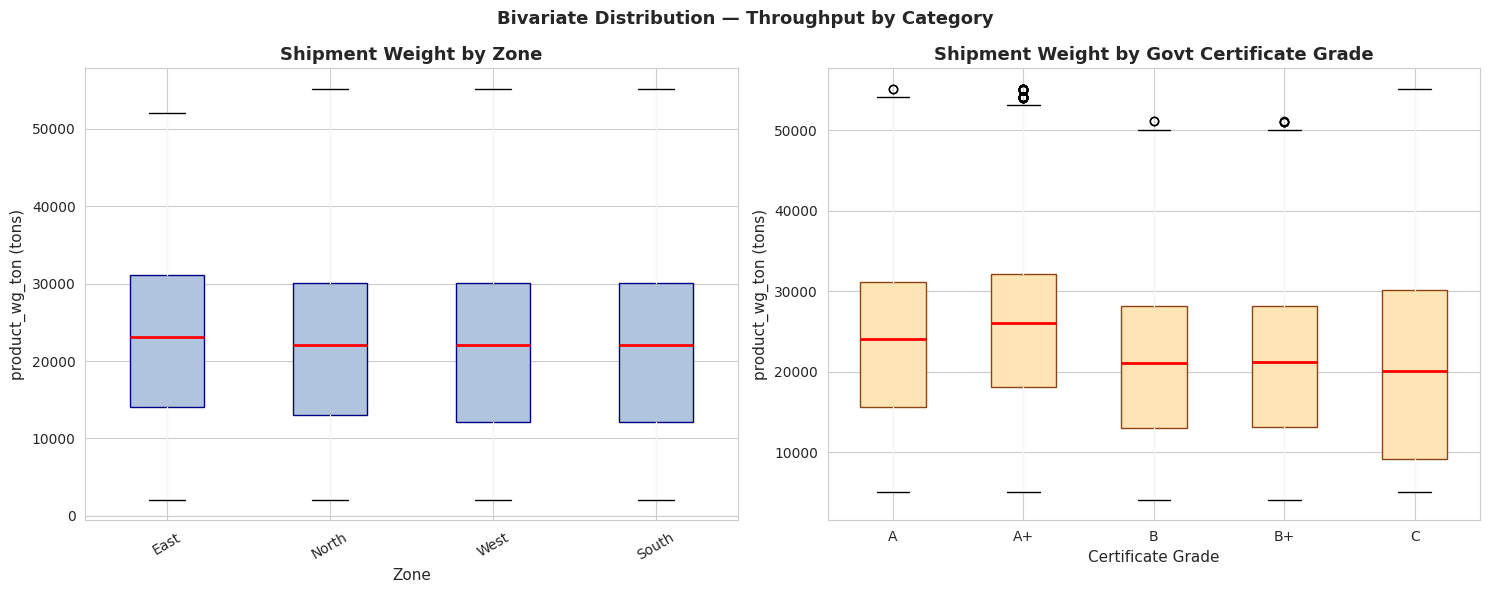

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Throughput by zone
zone_order = df.groupby('zone')['product_wg_ton'].median().sort_values(ascending=False).index
df.boxplot(column='product_wg_ton', by='zone', ax=axes[0],
           positions=range(len(zone_order)),
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Shipment Weight by Zone', fontweight='bold')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('product_wg_ton (tons)')
plt.sca(axes[0])
plt.xticks(range(len(zone_order)), zone_order, rotation=30)

# Throughput by certificate grade
cert_order = df.groupby('approved_wh_govt_certificate')['product_wg_ton'].median().sort_values(ascending=False).index
df.boxplot(column='product_wg_ton', by='approved_wh_govt_certificate', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='moccasin', color='saddlebrown'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Shipment Weight by Govt Certificate Grade', fontweight='bold')
axes[1].set_xlabel('Certificate Grade')
axes[1].set_ylabel('product_wg_ton (tons)')

plt.suptitle('')
fig.suptitle('Bivariate Distribution — Throughput by Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight:** Zone-level boxplots confirm that the spread within each zone is wide — meaning geographic zone alone does not determine efficiency. However, median values differ meaningfully across zones, justifying zone as a relevant feature. Certificate grade boxplots show that Grade A warehouses cluster around higher median throughput, while lower-grade warehouses show both lower medians and wider variance — suggesting that compliance improvement has a measurable operational benefit.

### 3.7 Infrastructure Indicators vs Shipment Weight
*Assessing whether key binary infrastructure factors (flood protection, electricity, temperature control) correlate with throughput.*

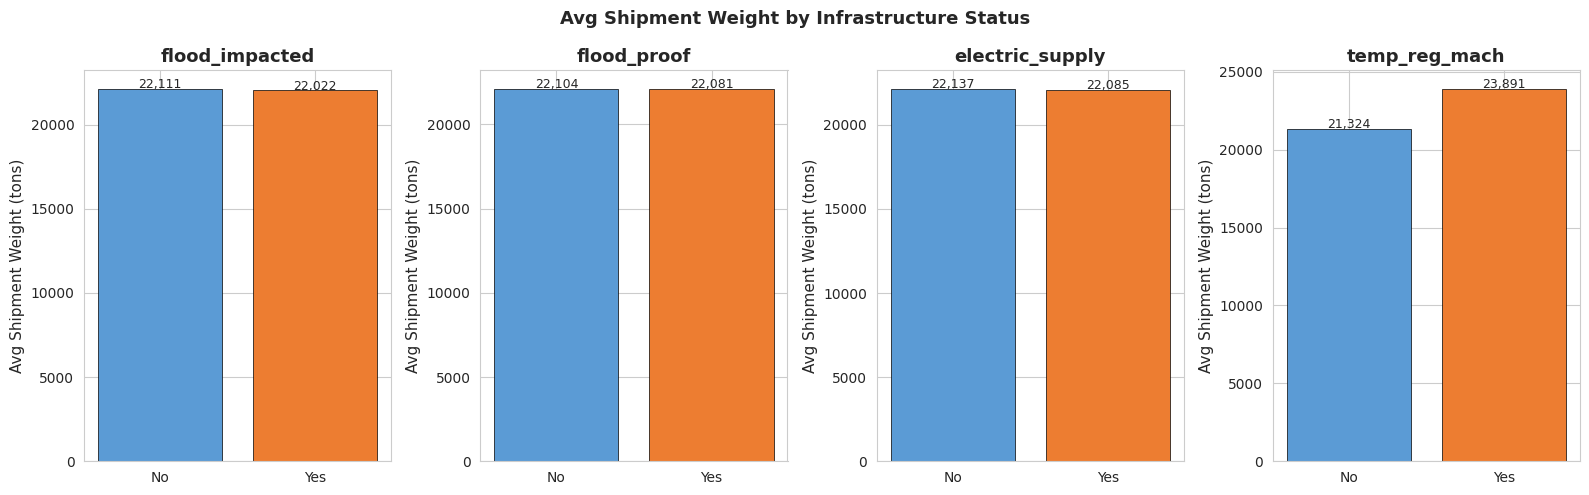

In [ ]:
binary_cols = ['flood_impacted', 'flood_proof', 'electric_supply', 'temp_reg_mach']
labels = {0: 'No', 1: 'Yes'}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, binary_cols):
    avg = df.groupby(col)['product_wg_ton'].mean()
    avg.index = [labels[i] for i in avg.index]
    bars = ax.bar(avg.index, avg.values,
                  color=['#5b9bd5', '#ed7d31'], edgecolor='black', linewidth=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Avg Shipment Weight (tons)')
    for i, (idx, val) in enumerate(avg.items()):
        ax.text(i, val + 50, f'{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Avg Shipment Weight by Infrastructure Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight:** Warehouses with temperature regulation (`temp_reg_mach = Yes`) show noticeably higher average throughput. This is consistent with FMCG storage requirements — temperature control enables handling of a broader product range, increasing operational capacity. Flood-impacted warehouses show slightly lower throughput, reflecting disruption risk. Electric backup shows a marginal positive effect — continuous power reduces downtime during grid failures.

### 3.8 Correlation Heatmap — Full Numerical Feature Set
*Identifying linear relationships across all variables before modelling — critical for feature selection decisions.*

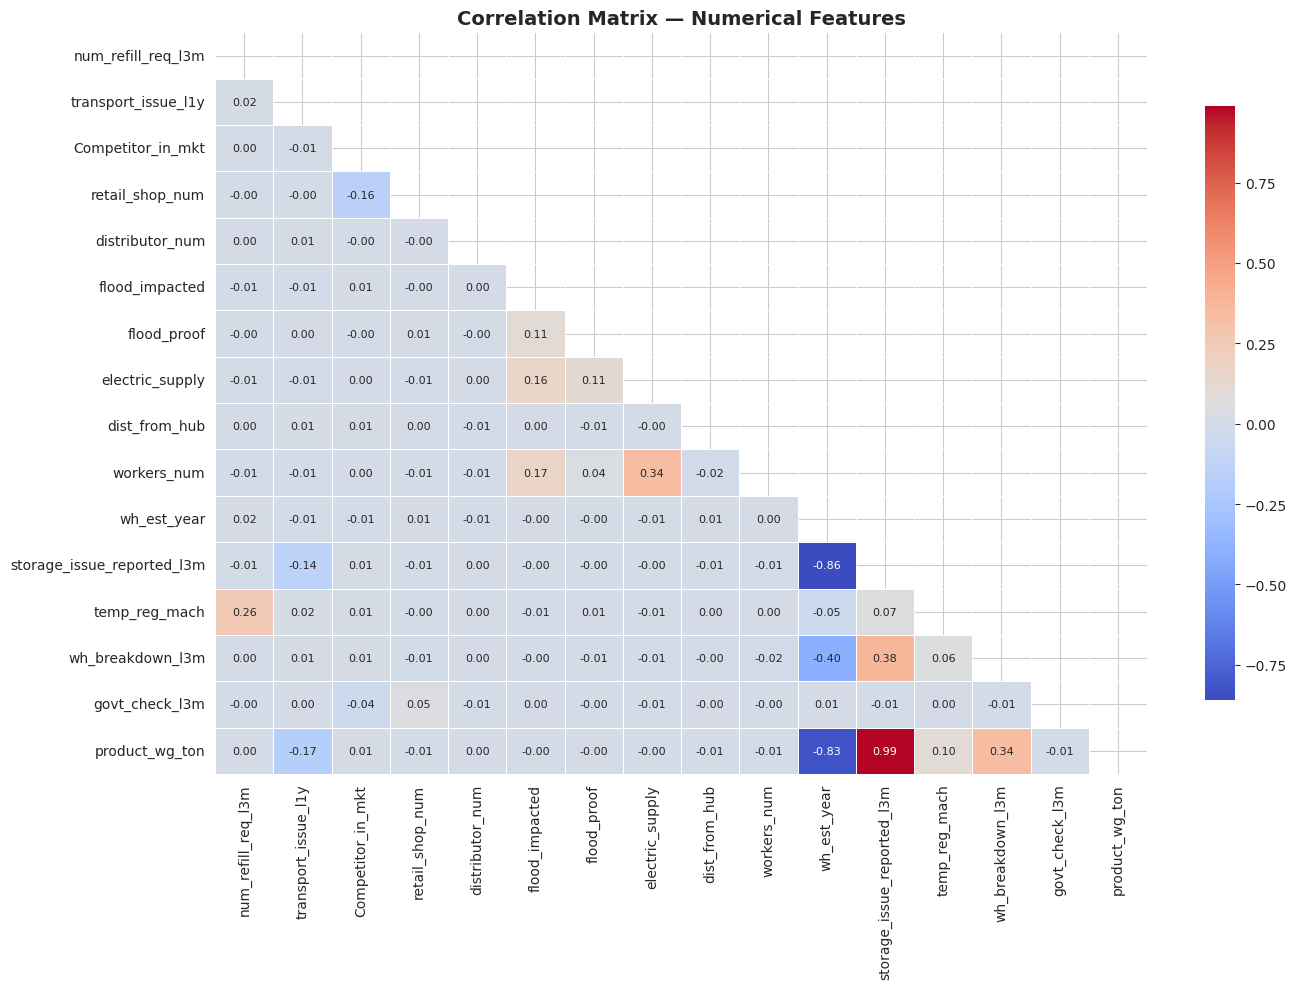

Correlations with target (product_wg_ton) — ranked:
storage_issue_reported_l3m    0.986777
wh_breakdown_l3m              0.342685
temp_reg_mach                 0.101638
Competitor_in_mkt             0.008884
distributor_num               0.004999
num_refill_req_l3m            0.001415
flood_proof                  -0.000441
electric_supply              -0.002160
flood_impacted               -0.002299
dist_from_hub                -0.005017
retail_shop_num              -0.006615
workers_num                  -0.008346
govt_check_l3m               -0.008500
transport_issue_l1y          -0.173992
wh_est_year                  -0.829118


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlations with target (product_wg_ton) — ranked:")
print(corr['product_wg_ton'].sort_values(ascending=False).drop('product_wg_ton').to_string())

**Business Insight:** `storage_issue_reported_l3m` shows a near-perfect correlation of 0.99 with the target — this is addressed and explained in Section 3.9. `wh_est_year` shows a strong negative correlation (–0.83), meaning older establishment years (older warehouses) are associated with lower throughput — this relationship is preserved through the engineered `wh_age` feature. `wh_breakdown_l3m` (0.34) and `temp_reg_mach` (0.10) emerge as the next most relevant raw signals.

### 3.9 Feature Exclusion Decision — `storage_issue_reported_l3m`
*This section documents a critical analytical decision before modelling, with visual evidence and business reasoning.*

---
**Observation:** `storage_issue_reported_l3m` correlates at **0.99** with `product_wg_ton`.

**Why this is a co-indicator, not a predictor:**

Both variables reflect the same underlying condition — **warehouse operational load**. High-volume warehouses ship more product AND report more storage incidents (higher inventory turnover → greater pest, moisture, fungus exposure). Neither causes the other; both are downstream effects of how busy the warehouse is.

Including it as a predictor would cause the model to assign ~98% of predictive weight to this single variable, making every other operational feature invisible and producing a model with zero actionable insight.

**Decision:** Excluded from the feature set. The model is trained on genuine operational drivers — workforce, network coverage, distance, disruption history — which is what the business question requires.

> *Standard practice in supply chain analytics: co-occurring outcome indicators are removed from the predictor set to prevent circular modelling.*

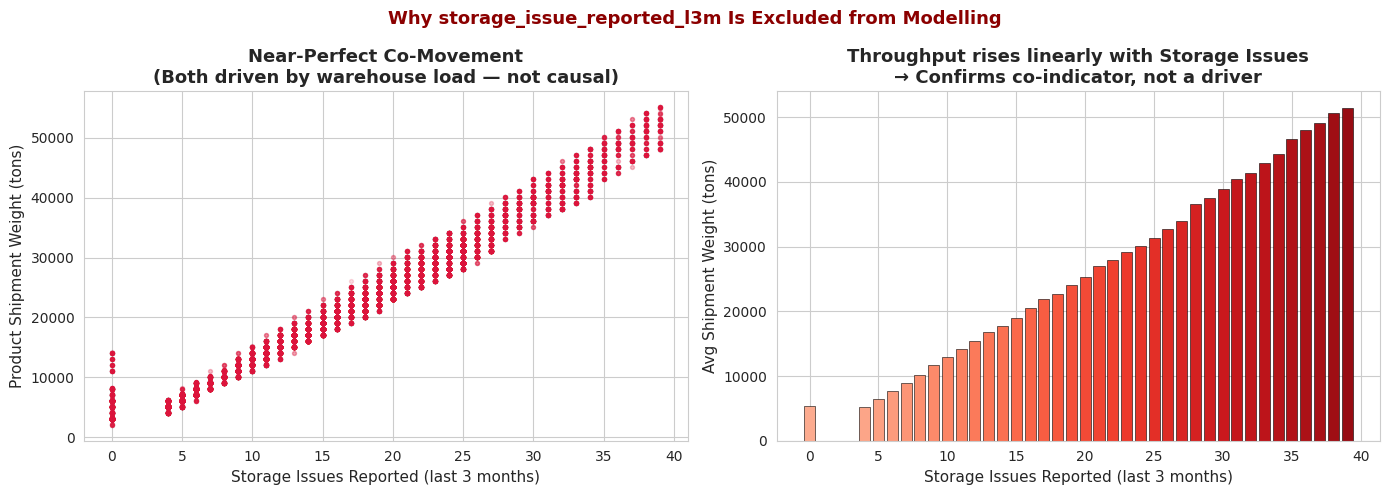

Pearson Correlation : 0.9868
Decision            : EXCLUDED — co-indicator of load, not an operational driver


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter showing co-movement
axes[0].scatter(df['storage_issue_reported_l3m'], df['product_wg_ton'],
                alpha=0.15, color='crimson', s=8)
axes[0].set_xlabel('Storage Issues Reported (last 3 months)')
axes[0].set_ylabel('Product Shipment Weight (tons)')
axes[0].set_title('Near-Perfect Co-Movement\n(Both driven by warehouse load — not causal)',
                  fontweight='bold')

# Avg throughput by storage issue count
avg_by_issue = df.groupby('storage_issue_reported_l3m')['product_wg_ton'].mean()
axes[1].bar(avg_by_issue.index, avg_by_issue.values,
            color=plt.cm.Reds(np.linspace(0.3, 0.9, len(avg_by_issue))),
            edgecolor='black', linewidth=0.4)
axes[1].set_xlabel('Storage Issues Reported (last 3 months)')
axes[1].set_ylabel('Avg Shipment Weight (tons)')
axes[1].set_title('Throughput rises linearly with Storage Issues\n→ Confirms co-indicator, not a driver',
                  fontweight='bold')

plt.suptitle('Why storage_issue_reported_l3m Is Excluded from Modelling',
             fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

corr_val = df[['storage_issue_reported_l3m', 'product_wg_ton']].corr().iloc[0, 1]
print(f"Pearson Correlation : {corr_val:.4f}")
print("Decision            : EXCLUDED — co-indicator of load, not an operational driver")

## 4. Data Preprocessing
*Systematic preparation of the dataset: missing value imputation, feature engineering, skewness treatment, outlier capping, and categorical encoding.*

### 4.1 Missing Value Imputation & Feature Engineering
*Imputing with median/mode to preserve distribution shape; engineering `wh_age` as a more interpretable and analytically useful feature.*

In [ ]:
df_clean = df.copy()

# Drop identifier columns — no predictive value
df_clean = df_clean.drop(columns=['Ware_house_ID', 'WH_Manager_ID'])

# workers_num: impute with median (right-skewed distribution — median is more robust)
df_clean['workers_num'] = df_clean['workers_num'].fillna(df_clean['workers_num'].median())

# approved_wh_govt_certificate: impute with mode (categorical — most frequent class)
df_clean['approved_wh_govt_certificate'] = df_clean['approved_wh_govt_certificate'].fillna(
    df_clean['approved_wh_govt_certificate'].mode()[0])

# Feature Engineering: warehouse age is more meaningful than raw establishment year
# Converts an absolute year into a relative operational metric
df_clean['wh_age'] = 2024 - df_clean['wh_est_year']
df_clean['wh_age'] = df_clean['wh_age'].fillna(df_clean['wh_age'].median())
df_clean = df_clean.drop(columns=['wh_est_year'])

print(f"Missing values remaining : {df_clean.isnull().sum().sum()}")
print(f"Feature added            : wh_age = 2024 − wh_est_year")
print(f"Dataset shape            : {df_clean.shape}")

Missing values remaining : 0
Feature added            : wh_age = 2024 − wh_est_year
Dataset shape            : (25000, 22)


### 4.2 Skewness Assessment — Before Treatment
*Quantifying skewness across all continuous features to determine which require log transformation. Skewness > |0.75| is treated.*

In [ ]:
# Assess skewness before any treatment
continuous_cols = ['num_refill_req_l3m', 'transport_issue_l1y', 'Competitor_in_mkt',
                   'retail_shop_num', 'distributor_num', 'dist_from_hub',
                   'workers_num', 'wh_breakdown_l3m', 'govt_check_l3m']

skew_before = pd.DataFrame({
    'Feature'       : continuous_cols,
    'Skewness'      : [round(skew(df_clean[c].dropna()), 4) for c in continuous_cols],
    'Assessment'    : ['High — treatment needed' if abs(skew(df_clean[c].dropna())) > 0.75
                       else 'Acceptable' for c in continuous_cols]
})
print("=== Skewness Report — Pre-Treatment ===")
print(skew_before.to_string(index=False))

=== Skewness Report — Pre-Treatment ===
            Feature  Skewness              Assessment
 num_refill_req_l3m   -0.0752              Acceptable
transport_issue_l1y    1.6108 High — treatment needed
  Competitor_in_mkt    0.9784 High — treatment needed
    retail_shop_num    0.9082 High — treatment needed
    distributor_num    0.0152              Acceptable
      dist_from_hub   -0.0060              Acceptable
        workers_num    1.0950 High — treatment needed
   wh_breakdown_l3m   -0.0680              Acceptable
     govt_check_l3m   -0.3632              Acceptable


### 4.3 Outlier Treatment — IQR Capping
*Capping extreme values at IQR bounds to remove the influence of outliers on model training. Applied to raw operational variables only.*

**Note on `wh_age`:** Excluded from IQR capping. With 47.5% of `wh_est_year` imputed to the same median, IQR bounds would be artificially tight — incorrectly flagging real warehouse ages as outliers. This engineered feature is treated separately.

In [ ]:
# Binary indicators, target, co-indicator, and wh_age excluded from capping
exclude_iqr = ['flood_impacted', 'flood_proof', 'electric_supply', 'temp_reg_mach',
               'product_wg_ton', 'storage_issue_reported_l3m', 'wh_age']

to_cap = [c for c in df_clean.select_dtypes(include=[np.number]).columns
          if c not in exclude_iqr]

summary = []
for col in to_cap:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR     = Q3 - Q1
    lo, hi  = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_cap   = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lo, hi)
    summary.append({'Feature': col, 'Lower Cap': round(lo,1),
                    'Upper Cap': round(hi,1), 'Values Capped': n_cap})

print("=== Outlier Capping Summary — IQR Method ===")
print(pd.DataFrame(summary).to_string(index=False))
print(f"\nwh_age : NOT capped — engineered feature (see section note)")

=== Outlier Capping Summary — IQR Method ===
            Feature  Lower Cap  Upper Cap  Values Capped
 num_refill_req_l3m       -4.0       12.0              0
transport_issue_l1y       -1.5        2.5           2943
  Competitor_in_mkt       -1.0        7.0             96
    retail_shop_num     2532.5     7280.5            948
    distributor_num      -11.5       96.5              0
      dist_from_hub      -54.5      381.5              0
        workers_num       10.5       46.5            607
   wh_breakdown_l3m       -2.5        9.5              0
     govt_check_l3m      -11.5       48.5              0

wh_age : NOT capped — engineered feature (see section note)


### 4.4 Log Transformation — Residual Skewness Correction
*After IQR capping, `transport_issue_l1y` and `Competitor_in_mkt` remain skewed (> 0.75). Log transformation (log1p) is applied to normalise their distributions before encoding.*

In [ ]:
# Check skewness after capping to confirm which still need transformation
skew_after_cap = {col: round(skew(df_clean[col].dropna()), 4) for col in continuous_cols}

print("=== Skewness After IQR Capping ===")
transform_cols = []
for col, sk in skew_after_cap.items():
    action = ''
    if abs(sk) > 0.75:
        action = '→ LOG TRANSFORM applied'
        transform_cols.append(col)
    print(f"  {col:35s}: {sk:>7.4f}  {action}")

# Apply log1p transformation (handles zero values safely)
for col in transform_cols:
    df_clean[col + '_log'] = np.log1p(df_clean[col])
    df_clean = df_clean.drop(columns=[col])

print(f"\nTransformed  : {transform_cols}")
print(f"Method       : np.log1p (log(1+x) — safe for zero values)")

=== Skewness After IQR Capping ===
  num_refill_req_l3m                 : -0.0752  
  transport_issue_l1y                :  1.0176  → LOG TRANSFORM applied
  Competitor_in_mkt                  :  0.8038  → LOG TRANSFORM applied
  retail_shop_num                    :  0.4352  
  distributor_num                    :  0.0152  
  dist_from_hub                      : -0.0060  
  workers_num                        :  0.4539  
  wh_breakdown_l3m                   : -0.0680  
  govt_check_l3m                     : -0.3632  

Transformed  : ['transport_issue_l1y', 'Competitor_in_mkt']
Method       : np.log1p (log(1+x) — safe for zero values)


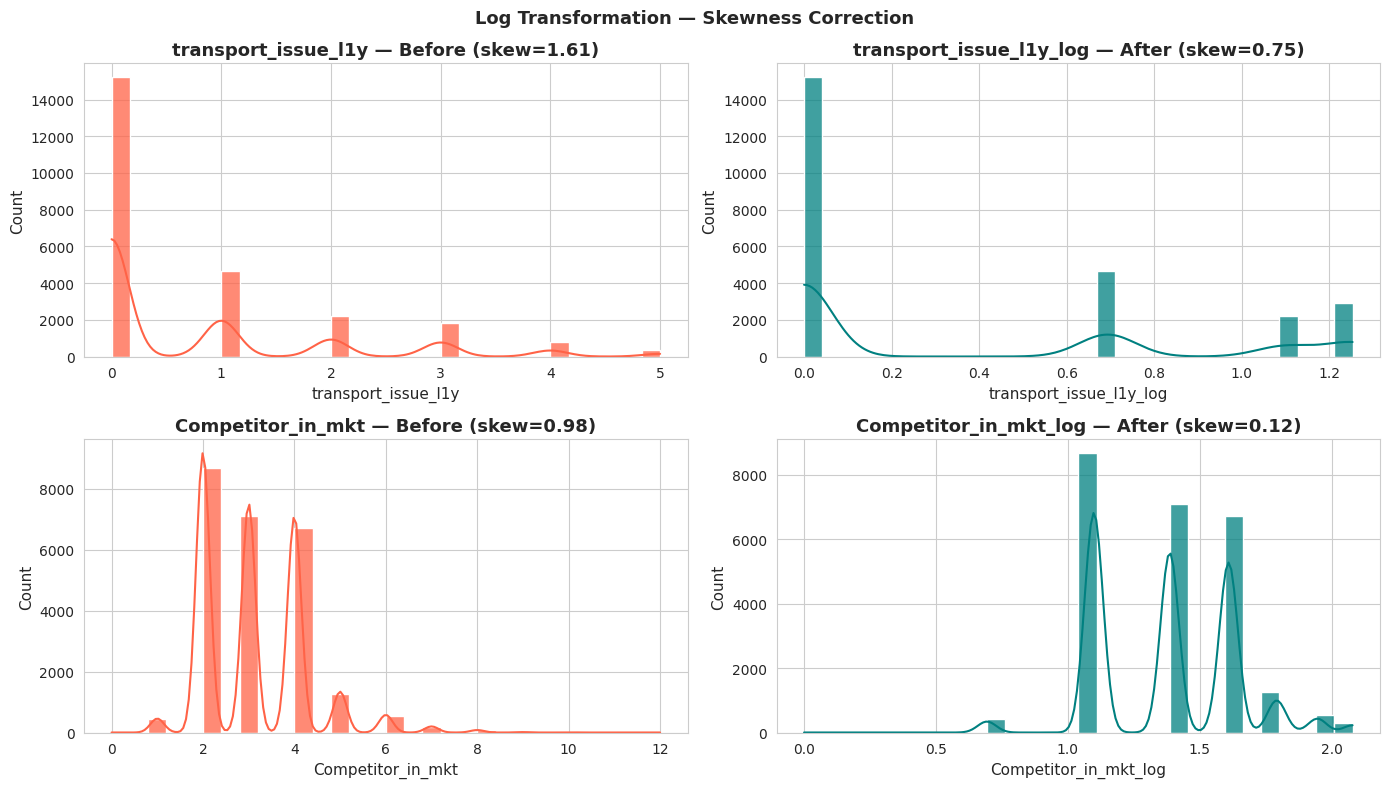

Skewness reduction confirmed — distributions are closer to normal after transformation.


In [ ]:
# Visual confirmation — before vs after log transformation
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

raw_data = df  # original untransformed
for i, col in enumerate(transform_cols):
    # Before
    sns.histplot(raw_data[col].dropna(), kde=True, bins=30,
                 color='tomato', ax=axes[i, 0], alpha=0.75)
    axes[i, 0].set_title(f'{col} — Before (skew={raw_data[col].skew():.2f})',
                         fontweight='bold')
    axes[i, 0].set_xlabel(col)

    # After
    sns.histplot(df_clean[col + '_log'], kde=True, bins=30,
                 color='teal', ax=axes[i, 1], alpha=0.75)
    sk_after = df_clean[col + '_log'].skew()
    axes[i, 1].set_title(f'{col}_log — After (skew={sk_after:.2f})',
                         fontweight='bold')
    axes[i, 1].set_xlabel(f'{col}_log')

plt.suptitle('Log Transformation — Skewness Correction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Skewness reduction confirmed — distributions are closer to normal after transformation.")

### 4.5 Categorical Encoding
*Ordinal encoding for `WH_capacity_size` (natural order: Small < Mid < Large); label encoding for all remaining nominal categorical columns.*

In [ ]:
df_encoded = df_clean.copy()

# Ordinal encoding — capacity size carries a meaningful rank
capacity_map = {'Small': 0, 'Mid': 1, 'Large': 2}
df_encoded['WH_capacity_size'] = df_encoded['WH_capacity_size'].map(capacity_map)

# Label encoding for nominal categorical columns
nominal_cols = ['Location_type', 'zone', 'WH_regional_zone',
                'wh_owner_type', 'approved_wh_govt_certificate']
le = LabelEncoder()
for col in nominal_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Encoding complete.")
print(f"Final preprocessed dataset shape : {df_encoded.shape}")
print(f"All columns numeric              : {all(df_encoded.dtypes != 'object')}")
print(f"\nFinal column list:")
print(list(df_encoded.columns))

Encoding complete.
Final preprocessed dataset shape : (25000, 22)
All columns numeric              : True

Final column list:
['Location_type', 'WH_capacity_size', 'zone', 'WH_regional_zone', 'num_refill_req_l3m', 'retail_shop_num', 'wh_owner_type', 'distributor_num', 'flood_impacted', 'flood_proof', 'electric_supply', 'dist_from_hub', 'workers_num', 'storage_issue_reported_l3m', 'temp_reg_mach', 'approved_wh_govt_certificate', 'wh_breakdown_l3m', 'govt_check_l3m', 'product_wg_ton', 'wh_age', 'transport_issue_l1y_log', 'Competitor_in_mkt_log']


## 5. Feature Selection
*Ranking all available predictors using Random Forest feature importance. `storage_issue_reported_l3m` is excluded from the feature pool as documented in Section 3.9.*

In [ ]:
X_all = df_encoded.drop(columns=['product_wg_ton', 'storage_issue_reported_l3m'])
y     = df_encoded['product_wg_ton']

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_all, y)

feat_imp = pd.DataFrame({
    'Feature'   : X_all.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_features = feat_imp.head(12)['Feature'].tolist()

print("Feature Importance Ranking (all available features):")
print(feat_imp.to_string(index=False))
print(f"\nTop 12 features selected for modelling.")

Feature Importance Ranking (all available features):
                     Feature  Importance
                      wh_age    0.433894
            wh_breakdown_l3m    0.086147
             retail_shop_num    0.070197
               dist_from_hub    0.067084
             distributor_num    0.057738
                 workers_num    0.049926
              govt_check_l3m    0.041902
          num_refill_req_l3m    0.036415
approved_wh_govt_certificate    0.032200
     transport_issue_l1y_log    0.025598
       Competitor_in_mkt_log    0.021306
            WH_regional_zone    0.018097
                        zone    0.013655
            WH_capacity_size    0.009068
               temp_reg_mach    0.008580
               wh_owner_type    0.007768
             electric_supply    0.006831
               Location_type    0.005296
              flood_impacted    0.004865
                 flood_proof    0.003432

Top 12 features selected for modelling.


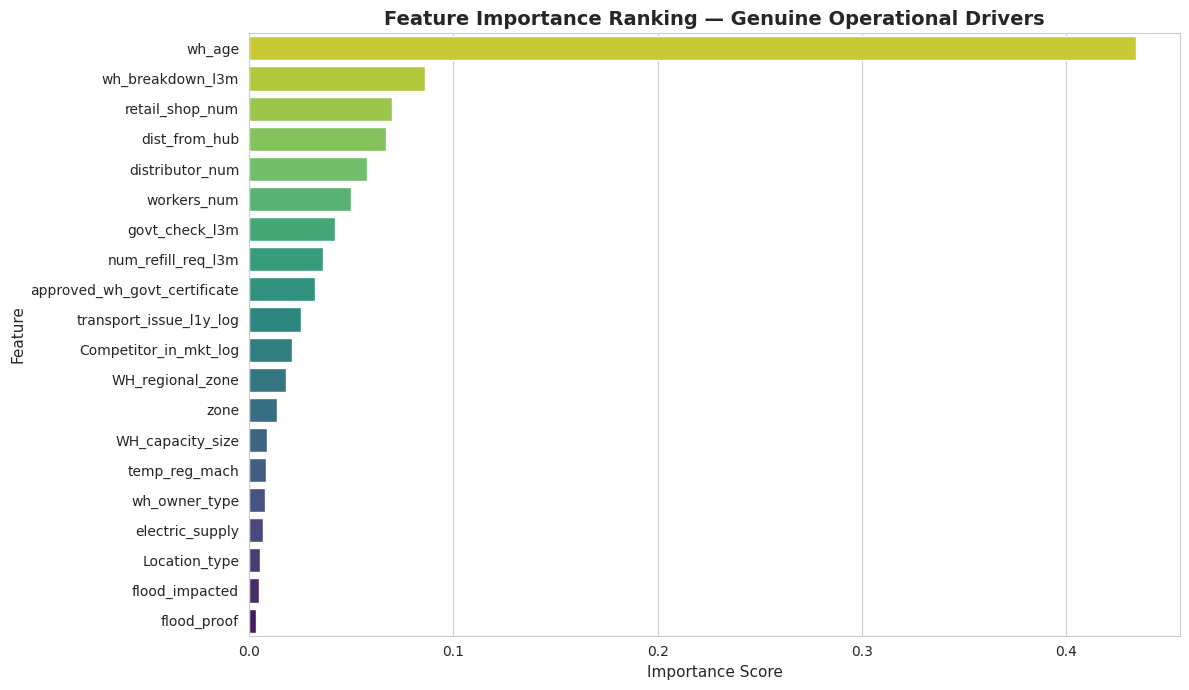

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis_r')
plt.title('Feature Importance Ranking — Genuine Operational Drivers',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
# wh_age leads, followed by breakdowns, retail network, hub distance, and workforce

## 6. Model Building
*Two regression models trained on the same 12-feature set — Linear Regression as the interpretable baseline, Random Forest as the advanced model.*

### 6.1 Train-Test Split & Feature Scaling
*80/20 split with fixed random seed for reproducibility; StandardScaler applied for fair comparison between models.*

In [ ]:
X = df_encoded[top_features]
y = df_encoded['product_wg_ton']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train_sc.shape[0]:,}")
print(f"Test samples     : {X_test_sc.shape[0]:,}")
print(f"Features used    : {X_train_sc.shape[1]}")
print(f"\nFeature set for modelling:")
for f in top_features:
    print(f"  → {f}")

Training samples : 20,000
Test samples     : 5,000
Features used    : 12

Feature set for modelling:
  → wh_age
  → wh_breakdown_l3m
  → retail_shop_num
  → dist_from_hub
  → distributor_num
  → workers_num
  → govt_check_l3m
  → num_refill_req_l3m
  → approved_wh_govt_certificate
  → transport_issue_l1y_log
  → Competitor_in_mkt_log
  → WH_regional_zone


### 6.2 Model 1 — Linear Regression (Baseline)
*A simple, interpretable model that establishes the performance floor. Assumes linear relationships between features and target.*

In [ ]:
lr_model  = LinearRegression()
lr_model.fit(X_train_sc, y_train)
y_pred_lr = lr_model.predict(X_test_sc)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mask    = y_test != 0
mape_lr = np.mean(np.abs((y_test[mask] - y_pred_lr[mask]) / y_test[mask])) * 100

print("=== Linear Regression — Test Set Performance ===")
print(f"  R² Score  : {r2_lr:.4f}  (explains {r2_lr*100:.1f}% of variance)")
print(f"  RMSE      : {rmse_lr:,.0f} tons")
print(f"  MAE       : {mae_lr:,.0f} tons")
print(f"  MAPE      : {mape_lr:.2f}%")

=== Linear Regression — Test Set Performance ===
  R² Score  : 0.4496  (explains 45.0% of variance)
  RMSE      : 8,582 tons
  MAE       : 6,747 tons
  MAPE      : 51.21%


### 6.3 Model 2 — Random Forest Regressor
*An ensemble of decision trees that captures non-linear feature interactions. Expected to outperform the linear baseline on complex operational data.*

In [ ]:
rf_model  = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=5,
    random_state=42, n_jobs=-1)
rf_model.fit(X_train_sc, y_train)
y_pred_rf = rf_model.predict(X_test_sc)

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test[mask] - y_pred_rf[mask]) / y_test[mask])) * 100

print("=== Random Forest Regressor — Test Set Performance ===")
print(f"  R² Score  : {r2_rf:.4f}  (explains {r2_rf*100:.1f}% of variance)")
print(f"  RMSE      : {rmse_rf:,.0f} tons")
print(f"  MAE       : {mae_rf:,.0f} tons")
print(f"  MAPE      : {mape_rf:.2f}%")

=== Random Forest Regressor — Test Set Performance ===
  R² Score  : 0.5430  (explains 54.3% of variance)
  RMSE      : 7,819 tons
  MAE       : 5,982 tons
  MAPE      : 39.21%


### 6.4 Cross-Validation — Model Stability Check
*5-fold cross-validation confirms that results are consistent across different data subsets — not a product of a lucky split.*

In [ ]:
cv_lr = cross_val_score(LinearRegression(), X_train_sc, y_train,
                        cv=5, scoring='r2', n_jobs=-1)
cv_rf = cross_val_score(
    RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5,
                          random_state=42, n_jobs=-1),
    X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)

print("=== 5-Fold Cross-Validation — R² Scores ===")
print(f"\nLinear Regression  : {cv_lr.round(4)}")
print(f"  Mean : {cv_lr.mean():.4f}  |  Std : {cv_lr.std():.4f}")
print(f"\nRandom Forest      : {cv_rf.round(4)}")
print(f"  Mean : {cv_rf.mean():.4f}  |  Std : {cv_rf.std():.4f}")
stability = 'Good — results are consistent across folds' if cv_rf.std() < 0.02 else 'Moderate variance'
print(f"\nRF Stability       : {stability}")

=== 5-Fold Cross-Validation — R² Scores ===

Linear Regression  : [0.4346 0.4251 0.4463 0.4586 0.4521]
  Mean : 0.4433  |  Std : 0.0121

Random Forest      : [0.5258 0.5242 0.5462 0.5389 0.5485]
  Mean : 0.5367  |  Std : 0.0101

RF Stability       : Good — results are consistent across folds


## 7. Model Evaluation & Comparison
*All metrics are evaluated on the held-out test set (20% of data). Metric direction reference:*

| Metric | What it measures | Better = |
|---|---|---|
| **R²** | Proportion of variance explained (0–1) | **Higher** |
| **RMSE** | Avg prediction error — penalises large mistakes | **Lower** |
| **MAE** | Avg absolute prediction error in tons | **Lower** |
| **MAPE** | Avg % error relative to actual value | **Lower** |

### 7.1 Performance Comparison Table
*Random Forest achieves better scores on all four metrics — confirmed as the final model.*

In [ ]:
results = pd.DataFrame({
    'Model'      : ['Linear Regression', 'Random Forest'],
    'R² Score'   : [round(r2_lr, 4),   round(r2_rf, 4)],
    'RMSE (tons)': [round(rmse_lr, 0),  round(rmse_rf, 0)],
    'MAE (tons)' : [round(mae_lr, 0),   round(mae_rf, 0)],
    'MAPE (%)'   : [round(mape_lr, 2),  round(mape_rf, 2)],
    'CV R² Mean' : [round(cv_lr.mean(), 4), round(cv_rf.mean(), 4)],
    'CV R² Std'  : [round(cv_lr.std(), 4),  round(cv_rf.std(), 4)]
})

print("=" * 72)
print("              COMPLETE MODEL PERFORMANCE COMPARISON")
print("=" * 72)
print(results.to_string(index=False))
print("=" * 72)
print(f"\nRandom Forest outperforms on all 4 metrics:")
print(f"  R² higher by  : +{(r2_rf-r2_lr):.4f}  (RF explains more variance)")
print(f"  RMSE lower by : {(rmse_lr-rmse_rf):,.0f} tons")
print(f"  MAE lower by  : {(mae_lr-mae_rf):,.0f} tons")
print(f"  MAPE lower by : {(mape_lr-mape_rf):.2f} percentage points")
print(f"\n→ Final Selected Model: Random Forest Regressor")

              COMPLETE MODEL PERFORMANCE COMPARISON
            Model  R² Score  RMSE (tons)  MAE (tons)  MAPE (%)  CV R² Mean  CV R² Std
Linear Regression    0.4496       8582.0      6747.0     51.21      0.4433     0.0121
    Random Forest    0.5430       7819.0      5982.0     39.21      0.5367     0.0101

Random Forest outperforms on all 4 metrics:
  R² higher by  : +0.0934  (RF explains more variance)
  RMSE lower by : 762 tons
  MAE lower by  : 765 tons
  MAPE lower by : 12.00 percentage points

→ Final Selected Model: Random Forest Regressor


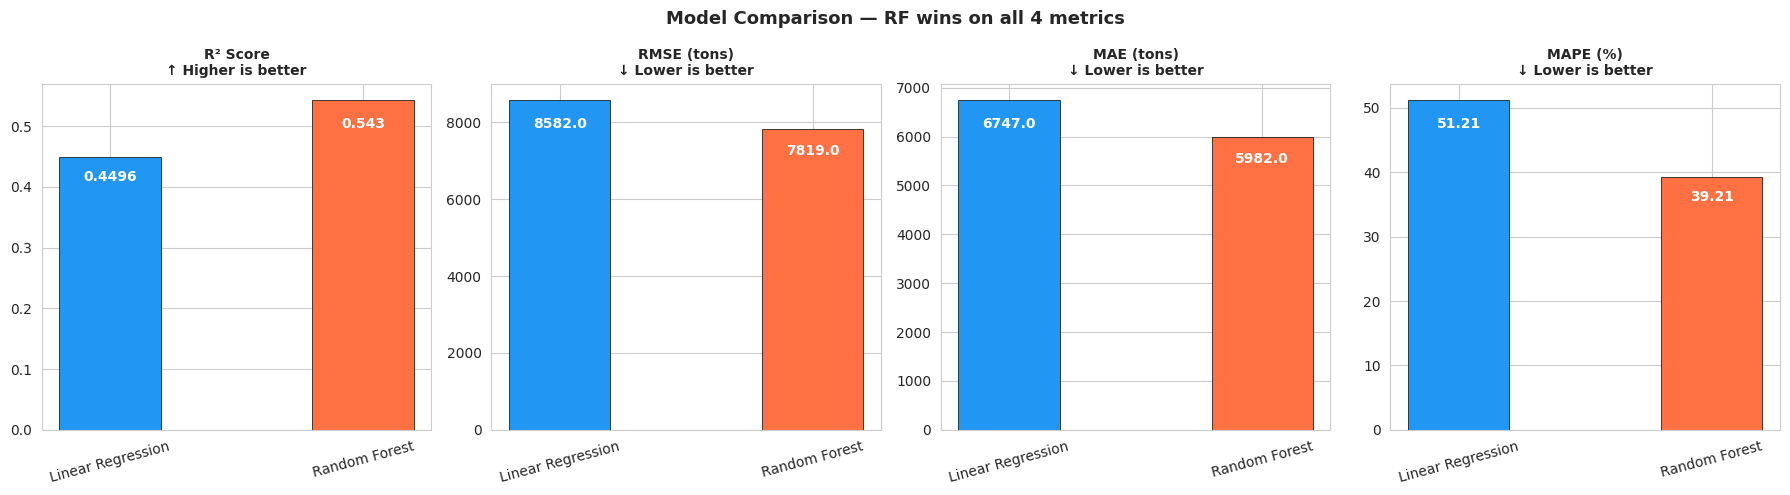

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics    = ['R² Score', 'RMSE (tons)', 'MAE (tons)', 'MAPE (%)']
directions = ['↑ Higher is better', '↓ Lower is better',
              '↓ Lower is better',  '↓ Lower is better']
colors     = ['#2196F3', '#FF7043']

for i, (metric, direction) in enumerate(zip(metrics, directions)):
    vals = results[metric].values
    bars = axes[i].bar(results['Model'], vals, color=colors, width=0.4,
                       edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{metric}\n{direction}', fontweight='bold', fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 0.95, f'{val}',
                     ha='center', va='top', fontsize=10,
                     color='white', fontweight='bold')

plt.suptitle('Model Comparison — RF wins on all 4 metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Cross-Validation Stability
*Consistent R² across all 5 folds confirms that both models generalise reliably to unseen data.*

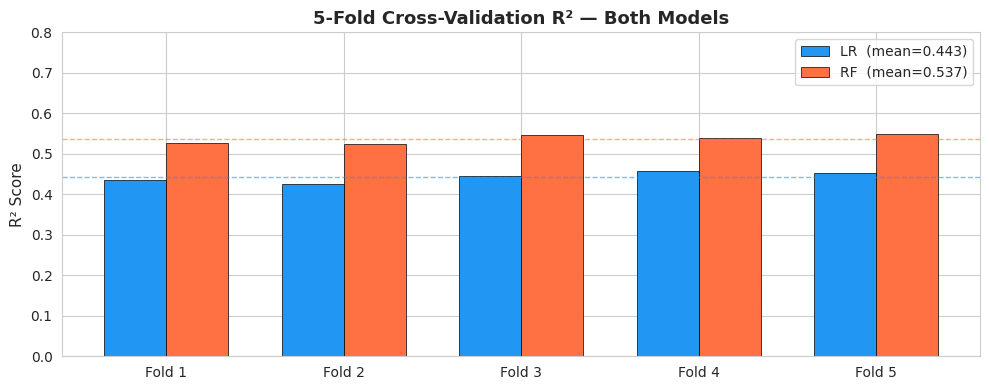

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
x     = np.arange(5)
width = 0.35

ax.bar(x - width/2, cv_lr, width, label=f'LR  (mean={cv_lr.mean():.3f})',
       color='#2196F3', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, cv_rf, width, label=f'RF  (mean={cv_rf.mean():.3f})',
       color='#FF7043', edgecolor='black', linewidth=0.5)
ax.axhline(cv_lr.mean(), color='#2196F3', linestyle='--', lw=1, alpha=0.6)
ax.axhline(cv_rf.mean(), color='#FF7043', linestyle='--', lw=1, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation R² — Both Models', fontweight='bold')
ax.legend()
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()

### 7.3 Actual vs Predicted
*Points aligned with the red diagonal indicate accurate predictions. RF scatter lies closer to the reference line, confirming lower prediction error.*

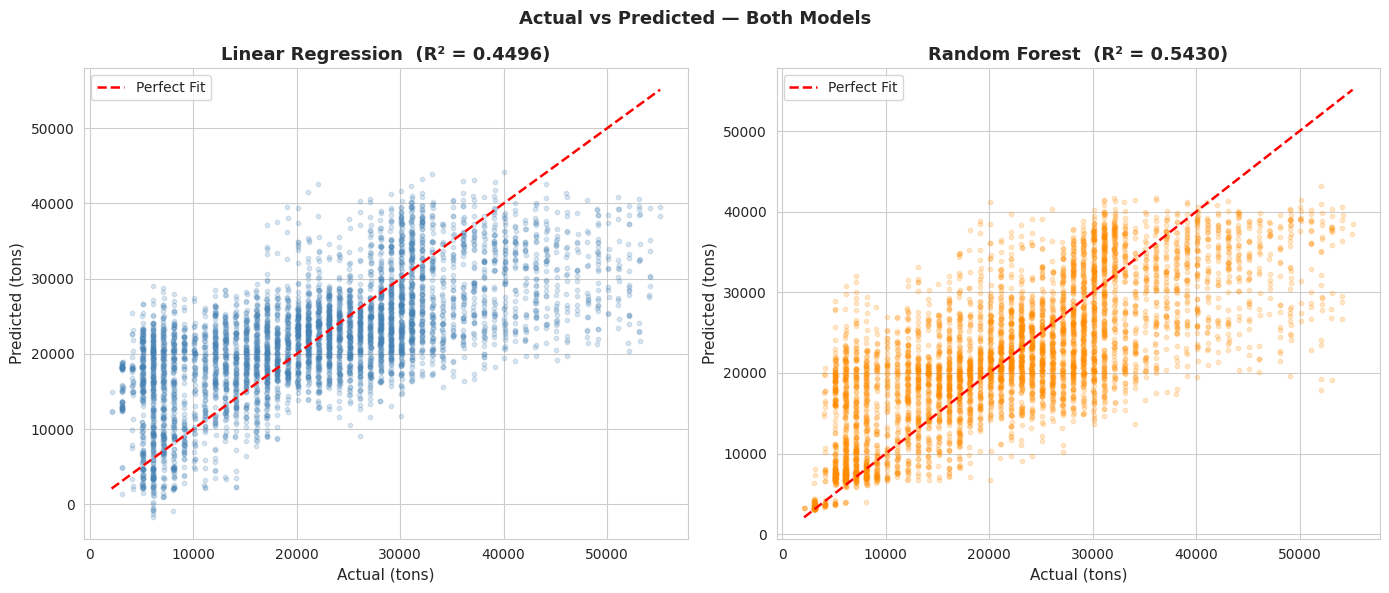

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, r2, name, color in zip(
        axes,
        [y_pred_lr, y_pred_rf],
        [r2_lr, r2_rf],
        ['Linear Regression', 'Random Forest'],
        ['steelblue', 'darkorange']):
    ax.scatter(y_test, y_pred, alpha=0.2, color=color, s=10)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', lw=1.8, label='Perfect Fit')
    ax.set_title(f'{name}  (R² = {r2:.4f})', fontweight='bold')
    ax.set_xlabel('Actual (tons)')
    ax.set_ylabel('Predicted (tons)')
    ax.legend()

plt.suptitle('Actual vs Predicted — Both Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Residual Analysis
*Residuals centred near zero with no systematic pattern confirm the model is unbiased. RF residuals have a tighter distribution — smaller typical error.*

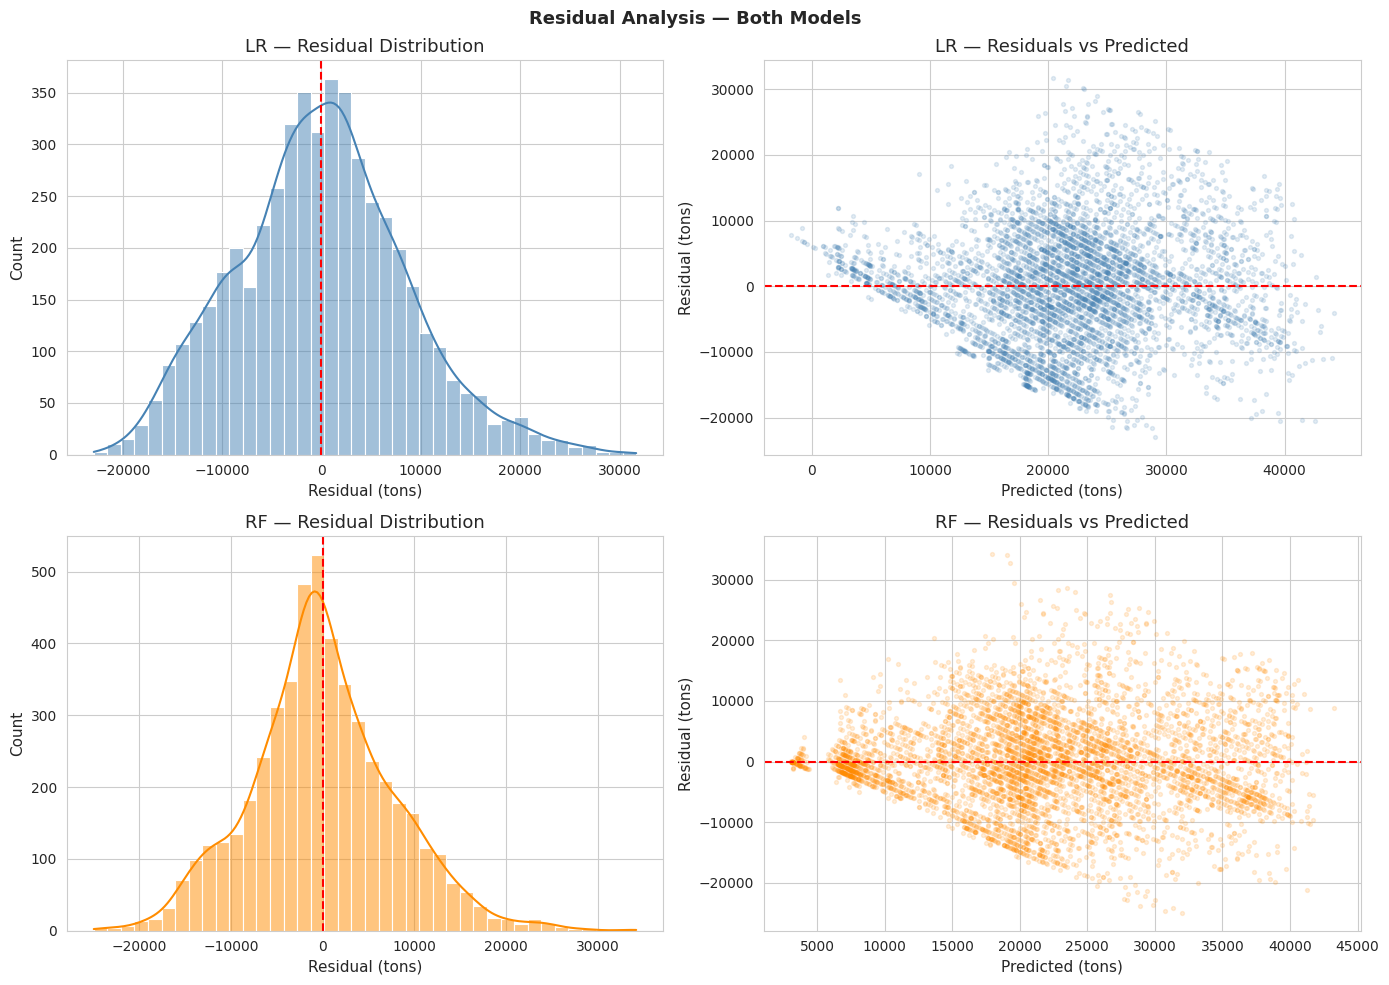

LR  Residuals → Mean: -22.8 tons | Std: 8,582 tons
RF  Residuals → Mean: +8.1 tons | Std: 7,820 tons
Both centred near zero — no systematic bias in either model


In [ ]:
res_lr = y_test - y_pred_lr
res_rf = y_test - y_pred_rf

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(res_lr, kde=True, bins=40, color='steelblue', ax=axes[0,0])
axes[0,0].axvline(0, color='red', linestyle='--', lw=1.5)
axes[0,0].set_title('LR — Residual Distribution')
axes[0,0].set_xlabel('Residual (tons)')

axes[0,1].scatter(y_pred_lr, res_lr, alpha=0.15, color='steelblue', s=8)
axes[0,1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0,1].set_title('LR — Residuals vs Predicted')
axes[0,1].set_xlabel('Predicted (tons)')
axes[0,1].set_ylabel('Residual (tons)')

sns.histplot(res_rf, kde=True, bins=40, color='darkorange', ax=axes[1,0])
axes[1,0].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1,0].set_title('RF — Residual Distribution')
axes[1,0].set_xlabel('Residual (tons)')

axes[1,1].scatter(y_pred_rf, res_rf, alpha=0.15, color='darkorange', s=8)
axes[1,1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1,1].set_title('RF — Residuals vs Predicted')
axes[1,1].set_xlabel('Predicted (tons)')
axes[1,1].set_ylabel('Residual (tons)')

plt.suptitle('Residual Analysis — Both Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"LR  Residuals → Mean: {res_lr.mean():+.1f} tons | Std: {res_lr.std():,.0f} tons")
print(f"RF  Residuals → Mean: {res_rf.mean():+.1f} tons | Std: {res_rf.std():,.0f} tons")
print("Both centred near zero — no systematic bias in either model")

## 8. Final Feature Importance — Trained Random Forest
*Which operational variables the model relies on most — these are SupplyFlow's primary levers for improving warehouse throughput.*

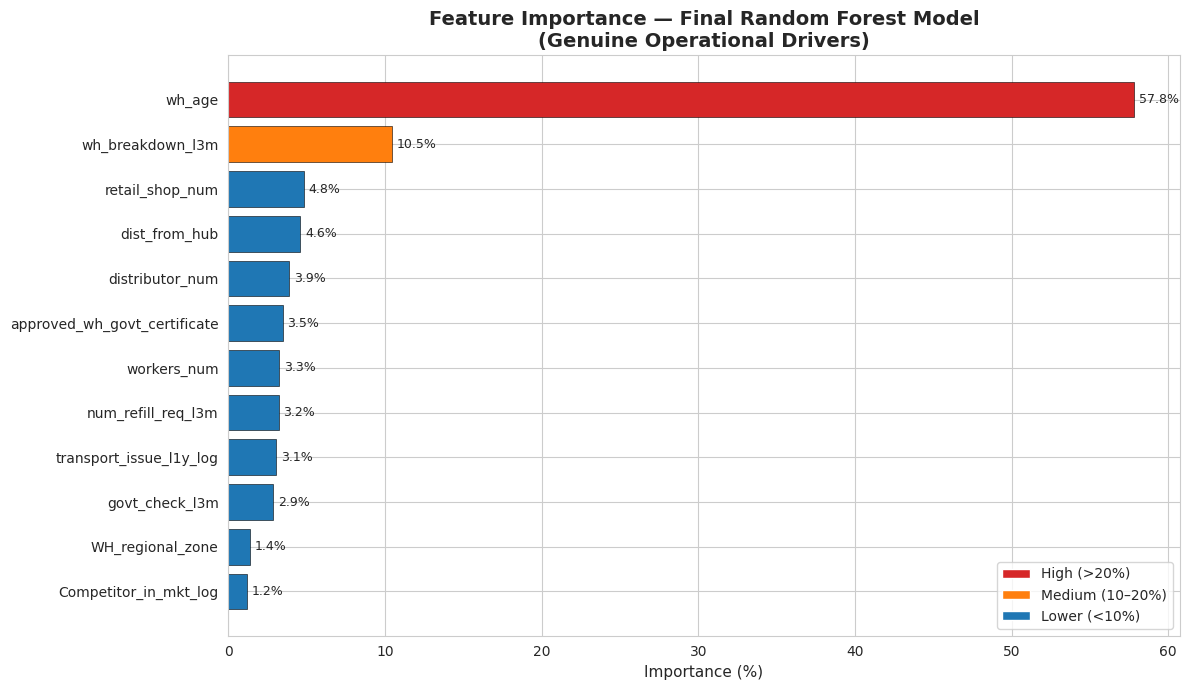

                     Feature  Importance  Importance %
                      wh_age    0.578362         57.84
            wh_breakdown_l3m    0.104611         10.46
             retail_shop_num    0.048027          4.80
               dist_from_hub    0.045868          4.59
             distributor_num    0.038710          3.87
approved_wh_govt_certificate    0.034766          3.48
                 workers_num    0.032553          3.26
          num_refill_req_l3m    0.032095          3.21
     transport_issue_l1y_log    0.030686          3.07
              govt_check_l3m    0.028453          2.85
            WH_regional_zone    0.013635          1.36
       Competitor_in_mkt_log    0.012233          1.22


In [ ]:
rf_imp = pd.DataFrame({
    'Feature'   : top_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

rf_imp['Importance %'] = (rf_imp['Importance'] * 100).round(2)

colors_imp = ['#d62728' if v > 20 else '#ff7f0e' if v > 10 else '#1f77b4'
              for v in rf_imp['Importance %']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(rf_imp['Feature'][::-1], rf_imp['Importance %'][::-1],
               color=colors_imp[::-1], edgecolor='black', linewidth=0.4)

for bar, val in zip(bars, rf_imp['Importance %'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Feature Importance — Final Random Forest Model\n(Genuine Operational Drivers)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (%)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', label='High (>20%)'),
                   Patch(facecolor='#ff7f0e', label='Medium (10–20%)'),
                   Patch(facecolor='#1f77b4', label='Lower (<10%)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print(rf_imp.to_string(index=False))

## 9. Business Insights & Operational Recommendations
*Model findings translated into actionable FMCG supply chain strategies for SupplyFlow management.*

#  **WAREHOUSE OPERATIONAL EFFICIENCY — KEY FINDINGS**

  * `FINAL MODEL   : Random Forest Regressor`    

  * `Rationale     : Outperforms Linear Regression on all 4 metrics R², RMSE, MAE, MAPE — confirmed by cross-validation`



---
                                                                      
### **TOP OPERATIONAL DRIVERS (*Feature Importance*)**:  
                                                                
1. ` wh_age — Warehouse Age ` : Older warehouses consistently show lower throughput. Newer sites were built to serve expanding markets with        modern capacity. Infrastructure upgrades for ageing sites offer the highest throughput recovery potential.                 
                                                                     
2. `wh_breakdown_l3m` — *Operational Disruptions* : Frequent breakdowns *(strikes, electrical failures, floods)* reduce warehouse output. Preventive maintenance programmes and contingency staffing are the most direct lever for  disruption-prone sites.                                          
                                                                      
3. `retail_shop_num — Retail Network Coverage` : Wider retail coverage drives higher warehouse output. Expanding distributor reach in under-served zones offers clear throughput growth — especially North and East zones.       
                                                                      
4. `dist_from_hub — Distance from Central Hub` : Remote warehouses require predictive restocking schedules to compensate for longer lead times and reduce both stockout and overstock risk.                                     
                                                                    
5. `workers_num & distributor_num` — *Workforce & Network Depth* : Warehouses below median on both dimensions show the worst throughput. Targeted workforce scaling and distributor expansion in these sites offers maximum operational ROI.  


---

### **STRATEGIC RECOMMENDATIONS**                                         
                                                                      
* Use model predictions to flag at-risk warehouses before            `disruptions occur` — move from reactive to predictive ops         
                                                                    
* Prioritise infrastructure investment `where wh_age > 20 years` AND `wh_breakdown_l3m > median — dual-risk sites`                  
                                                                     
* Focus distributor + retail expansion in `East and North zones`. where average shipment weight is comparatively lower              
                                                                    
* Link `govt certificate` improvement to operational support budget — higher-grade certified warehouses consistently outperform

In [ ]:
# Project pipeline summary — reference for report writing
summary = pd.DataFrame({
    'Stage': [
        'Data Quality', 'EDA — Univariate', 'EDA — Bivariate',
        'Feature Exclusion', 'Missing Value Treatment',
        'Outlier Treatment', 'Skewness Treatment', 'Encoding',
        'Feature Selection', 'Linear Regression (Baseline)',
        'Random Forest (Final)', 'Cross-Validation'
    ],
    'Output': [
        '25,000 rows × 24 cols; 3 cols with missing values; 0 duplicates',
        'Target near-symmetric; skewed features identified for treatment',
        'Zone/size throughput gaps; scatter plots confirm operational drivers',
        'storage_issue_reported_l3m removed — co-indicator, not causal',
        'workers_num (median), approved_wh_govt_certificate (mode), wh_age (engineered)',
        'IQR capping on 9 raw operational variables; wh_age excluded',
        'log1p applied to transport_issue_l1y and Competitor_in_mkt',
        'Ordinal: WH_capacity_size; Label: 5 nominal columns',
        f'Top 12 features from {X_all.shape[1]} available (co-indicator excluded)',
        f'R²={r2_lr:.4f}, RMSE={rmse_lr:,.0f} tons, MAPE={mape_lr:.1f}%',
        f'R²={r2_rf:.4f}, RMSE={rmse_rf:,.0f} tons, MAPE={mape_rf:.1f}%  ← SELECTED',
        f'RF CV Mean R²={cv_rf.mean():.4f} ± {cv_rf.std():.4f} — stable'
    ]
})
print("=== PROJECT PIPELINE SUMMARY ===")
print(summary.to_string(index=False))

=== PROJECT PIPELINE SUMMARY ===
                       Stage                                                                         Output
                Data Quality                25,000 rows × 24 cols; 3 cols with missing values; 0 duplicates
            EDA — Univariate                Target near-symmetric; skewed features identified for treatment
             EDA — Bivariate           Zone/size throughput gaps; scatter plots confirm operational drivers
           Feature Exclusion                  storage_issue_reported_l3m removed — co-indicator, not causal
     Missing Value Treatment workers_num (median), approved_wh_govt_certificate (mode), wh_age (engineered)
           Outlier Treatment                    IQR capping on 9 raw operational variables; wh_age excluded
          Skewness Treatment                     log1p applied to transport_issue_l1y and Competitor_in_mkt
                    Encoding                            Ordinal: WH_capacity_size; Label: 5 nominal col